# Group J - Problem Set 2

## Queueing Theory Simulations

In [20]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import random
import math
import pandas as pd

## a) Arrival and Service Rate Estimates

In [21]:
# data


arrival_nums = np.array([12, 12, 13, 11, 14, 12, 13, 15, 11, 13]) * 1/5
service_nums = np.array([15, 10, 17, 14, 13, 16, 12, 15, 14, 14]) * 1/5

arrival_rate_est = sum(arrival_nums)/len(arrival_nums)
service_rate_est = sum(service_nums)/len(service_nums)

print(f"Average Arrival Rate (per minute): {round(arrival_rate_est, 3)}")
print(f"Average Service Rate (per minute): {round(service_rate_est, 3)}")

Average Arrival Rate (per minute): 2.52
Average Service Rate (per minute): 2.8


## a) Visualisations for Part A

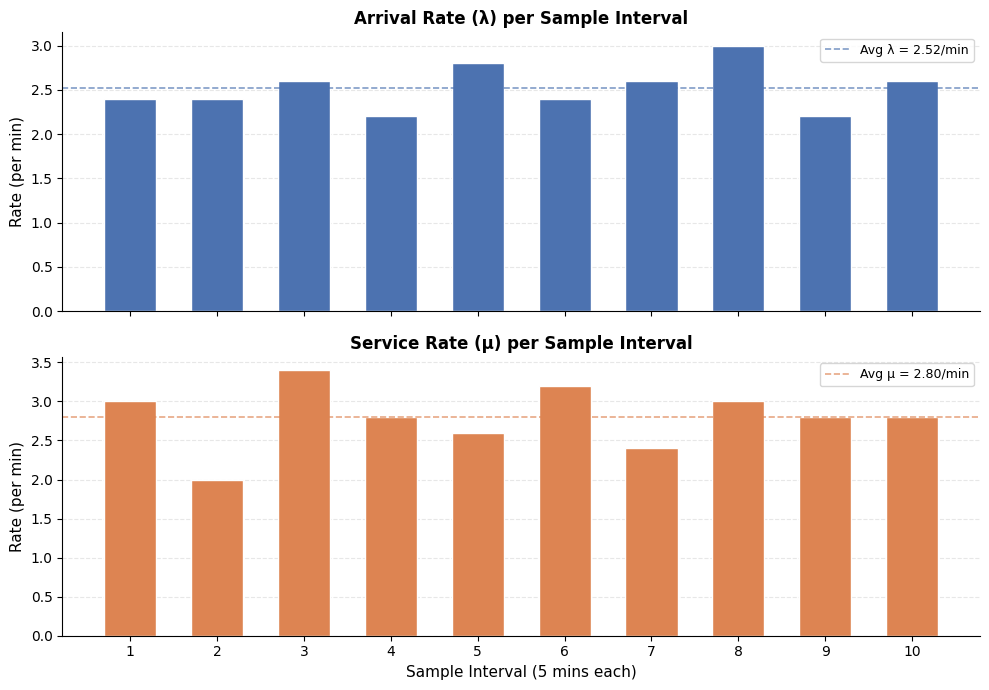

In [22]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

x = np.arange(1, len(arrival_nums) + 1)

# Arrival rates
ax1.bar(x, arrival_nums, color='#4C72B0', edgecolor='white', width=0.6)
ax1.axhline(y=arrival_rate_est, color='#4C72B0', linestyle='--', linewidth=1.2, alpha=0.7,
            label=f'Avg λ = {arrival_rate_est:.2f}/min')
ax1.set_ylabel('Rate (per min)', fontsize=11)
ax1.set_title('Arrival Rate (λ) per Sample Interval', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_axisbelow(True)
ax1.yaxis.grid(True, linestyle='--', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Service rates
ax2.bar(x, service_nums, color='#DD8452', edgecolor='white', width=0.6)
ax2.axhline(y=service_rate_est, color='#DD8452', linestyle='--', linewidth=1.2, alpha=0.7,
            label=f'Avg μ = {service_rate_est:.2f}/min')
ax2.set_xlabel('Sample Interval (5 mins each)', fontsize=11)
ax2.set_ylabel('Rate (per min)', fontsize=11)
ax2.set_title('Service Rate (μ) per Sample Interval', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.legend(fontsize=9)
ax2.set_axisbelow(True)
ax2.yaxis.grid(True, linestyle='--', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## b) M/M/1 Queue Simulation

In [23]:
# inverse-transform sampling for random numbers:
def exponential_sample(lamda):
    r = random.random()
    return -math.log(r) / lamda

def generate_samples(d):
    samples_interarrival = [exponential_sample(arrival_rate_est) for _ in range(d)]
    samples_service = [exponential_sample(service_rate_est) for _ in range(d)]
    return samples_interarrival, samples_service

In [24]:
# set up recursion function using Lindley's equation
def recurse_lindley(service_times, interarrival_times, d):
    
    waiting_times = [0]*d
    for i in range(d-1):
        waiting_times[i+1] = max(0, waiting_times[i] + service_times[i] - interarrival_times[i])
    time_in_system = [waiting_times[i] + service_times[i] for i in range(d)]

    avg_wait_queue = sum(waiting_times) / d
    avg_system_time = sum(time_in_system) / d
    return waiting_times

In [25]:
# record events (when customers enter or leave)
def record_events(service_times, interarrival_times, waiting_times, d):

    # generate events tracker
    arrival_times = [0]*d
    for i in range(1,d):
        arrival_times[i] = arrival_times[i-1] + interarrival_times[i-1]
    service_start_times = [arrival_times[i] + waiting_times[i] for i in range(d)]
    service_end_times = [service_start_times[i] + service_times[i] for i in range(d)]
    events = []
    for time in arrival_times:
        events.append((time, +1))
    for time in service_end_times:
        events.append((time, -1))
    events.sort()

    return events

# report required estimates from simulation run
def report_estimates(waiting_times, events, d):

    # i) estimate average queue length + iii) utilisation ratio
    time_server_occupied = 0
    previous_time = 0
    time_weighted_total_L = 0
    current_L = 0
    for time, change_L in events:
        time_delta = time - previous_time
        if current_L > 0:
            time_server_occupied += time_delta
        time_weighted_total_L += current_L * time_delta
        previous_time = time
        current_L += change_L
    average_L = time_weighted_total_L / previous_time
    utilisation_ratio = time_server_occupied / previous_time
    
    # ii) estimate average wait time
    average_wait = sum(waiting_times) / d

    return np.array([average_L, average_wait, utilisation_ratio])
    

In [26]:
# calculate theoretical values:
rho = arrival_rate_est / service_rate_est
expected_L = rho / (1 - rho)
expected_wait = rho / (service_rate_est - arrival_rate_est)

In [27]:
n = 100
d = 100000

estimates_list = []

for run in range(n):
    random.seed(run)
    samples_interarrival, samples_service = generate_samples(d)
    waiting_times = recurse_lindley(samples_service, samples_interarrival, d)
    events = record_events(samples_service, samples_interarrival, waiting_times, d)
    estimates = report_estimates(waiting_times, events, d)
    estimates_list.append(estimates)

estimates_array = np.array(estimates_list)
means = estimates_array.mean(axis=0)
stds = estimates_array.std(axis=0, ddof=1)
ci95 = 1.96 * stds / np.sqrt(n)

estimate_L, estimate_wait, estimate_utilisation_ratio = means
ci_L, ci_wait, ci_util = ci95
rho = arrival_rate_est / service_rate_est
expected_L = rho / (1 - rho)
expected_wait = rho / (service_rate_est - arrival_rate_est)

data = {
    "Metric": ["Queue Length (L)", "Waiting Time (mins)", "Utilisation Ratio"],
    "Theoretical": [expected_L, expected_wait, rho],
    "Monte Carlo Estimate": means,
    "95% CI (±)": ci95,
    "% Error": np.abs(means - [expected_L, expected_wait, rho]) / [expected_L, expected_wait, rho] * 100,
    "Coverage": [
        "Yes" if abs(means[0] - expected_L) <= ci_L else "No",
        "Yes" if abs(means[1] - expected_wait) <= ci_wait else "No",
        "Yes" if abs(means[2] - rho) <= ci_util else "No"
    ]
}

df = pd.DataFrame(data)
df[["Theoretical", "Monte Carlo Estimate"]] = df[["Theoretical", "Monte Carlo Estimate"]].round(4)
df["95% CI (±)"] = df["95% CI (±)"].round(4)
df["% Error"] = df["% Error"].round(3)

print("=== M/M/1 Queue: Theoretical vs Monte Carlo Estimates ===\n")
print(df.to_string(index=False))

=== M/M/1 Queue: Theoretical vs Monte Carlo Estimates ===

             Metric  Theoretical  Monte Carlo Estimate  95% CI (±)  % Error Coverage
   Queue Length (L)       9.0000                8.9193      0.1077    0.897      Yes
Waiting Time (mins)       3.2143                3.1844      0.0417    0.930      Yes
  Utilisation Ratio       0.9000                0.8990      0.0008    0.110       No


## b) Visualisations for M/M/1 Queue Simulation

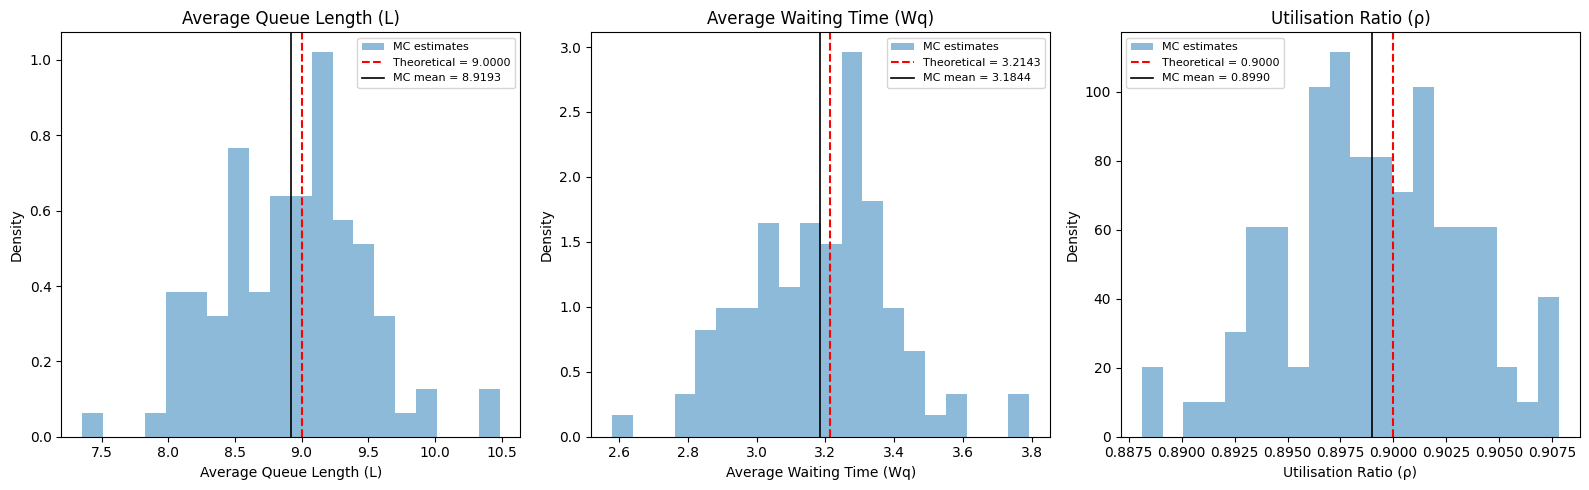

In [34]:
# Distribution of estimates across 100 Monte Carlo runs
plt.figure(figsize=(16, 5))

titles = ["Average Queue Length (L)", "Average Waiting Time (Wq)", "Utilisation Ratio (ρ)"]
theoretical = [expected_L, expected_wait, rho]

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.hist(estimates_array[:, i], bins=20, density=True, alpha=0.5, label="MC estimates")
    plt.axvline(theoretical[i], color='r', linestyle='--', linewidth=1.5,
                label=f"Theoretical = {theoretical[i]:.4f}")
    plt.axvline(means[i], color='black', linestyle='-', linewidth=1.2,
                label=f"MC mean = {means[i]:.4f}")
    plt.xlabel(titles[i])
    plt.ylabel("Density")
    plt.title(titles[i])
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

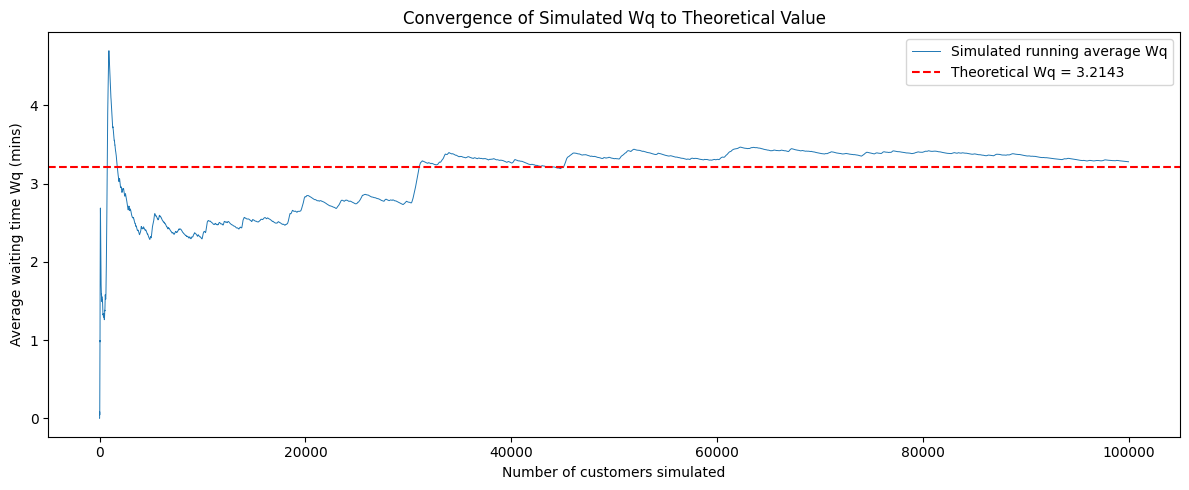

In [44]:
# Convergence of running average waiting time
random.seed(38)
samples_interarrival, samples_service = generate_samples(d)
waiting_times_conv = recurse_lindley(samples_service, samples_interarrival, d)

running_avg = np.cumsum(waiting_times_conv) / np.arange(1, d + 1)

plt.figure(figsize=(12, 5))
plt.plot(range(1, d + 1), running_avg, linewidth=0.7, label="Simulated running average Wq")
plt.axhline(y=expected_wait, color='r', linestyle='--', linewidth=1.5,
            label=f"Theoretical Wq = {expected_wait:.4f}")
plt.xlabel("Number of customers simulated")
plt.ylabel("Average waiting time Wq (mins)")
plt.title("Convergence of Simulated Wq to Theoretical Value")
plt.legend()
plt.tight_layout()
plt.show()

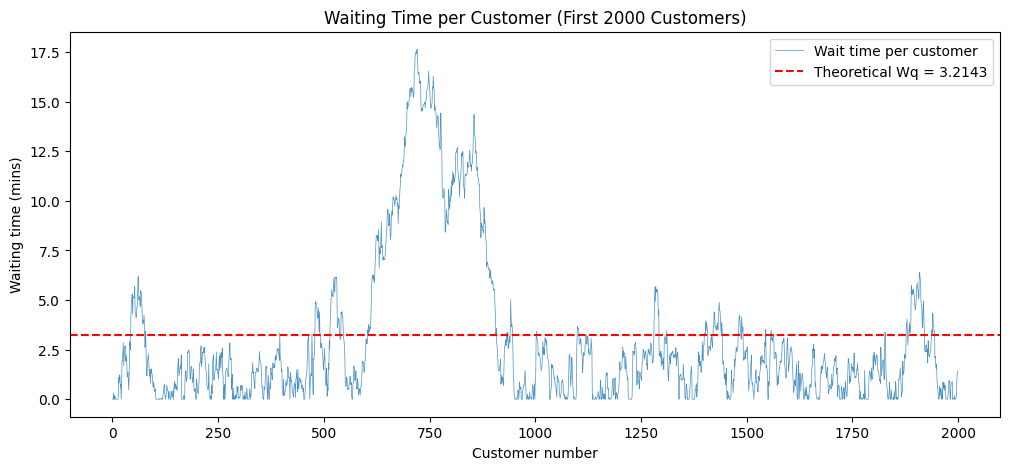

In [42]:
# Waiting time per customer (first 2000 from previous run)
plt.figure(figsize=(12, 5))
plt.plot(range(2000), waiting_times_conv[:2000], linewidth=0.5, alpha=0.8, label="Wait time per customer")
plt.axhline(y=expected_wait, color='r', linestyle='--', linewidth=1.5,
            label=f"Theoretical Wq = {expected_wait:.4f}")
plt.xlabel("Customer number")
plt.ylabel("Waiting time (mins)")
plt.title("Waiting Time per Customer (First 2000 Customers)")
plt.legend()
plt.show()

## c) Independent Queues Simulation

In the current cafeteria setup, all customers wait in a single shared queue and are served by the next available server (M/M/s configuration). Management is considering an alternative design where each server has its own independent queue, and customers choose which queue to join upon arrival.


**Assumptions:**
- The Japanese station has **s = 3** servers operating in parallel during rush hour.
- Each server has an individual service rate of μ_individual = μ_total / s, where μ_total is the aggregate rate estimated in Part A.
- The total arrival rate λ remains unchanged from Part A.
- The payment process occurs after food service in both the current and proposed configurations. Since it is common to both designs, it does not affect the relative comparison and is therefore excluded from the simulation. The waiting time estimates below reflect the food service queuing stage only.
- We compare several customer routing policies: random assignment, shortest queue, round robin, and shortest queue with jockeying.


**M/M/s Shared Queue (Current System):**
All customers wait in a single shared line. When any server becomes free, the next customer in line immediately moves to that server. This means no server ever sits idle while a customer is waiting as the assignment of customer to server happens at the moment of service, not at the moment of arrival.

**Independent Queues — Shortest Queue:**
Each server has its own separate line. When a customer arrives, they observe the current queue lengths and join the shortest one. However, they are now committed to that queue,  even if another server becomes free before they are served, they cannot switch. The key difference from M/M/s is the timing of the decision since customers commit to a server at arrival based on current conditions, which may change before they reach the front of their queue.

**Independent Queues — Round Robin:**
Customers are assigned to servers in a fixed rotating order (1, 2, 3, 1, 2, 3...) regardless of queue lengths. This ignores all information about the current state of the system, leading to imbalanced queues when service times vary.

**Independent Queues — Random:**
Each customer picks a queue uniformly at random. This ignores queue state and can lead to some servers being heavily overloaded while others sit idle.


### Decomposing the Service Rate

In Part A, we estimated the aggregate service rate μ = 2.80 customers/min by counting total service completions across all servers at the Japanese station. In Part B, we used this directly as a single combined server (M/M/1 simplification).

For Part C, we decompose this back into individual servers. With s = 3 servers observed at the station, each server has an individual service rate of μ_individual = 2.80 / 3 = 0.933 customers/min. The total throughput remains the same (3 × 0.933 = 2.80), but we can now model each server's queue independently.

In [46]:

s = 3  # number of servers observed
mu_individual = service_rate_est / s  # service rate per server

print(f"Number of servers: {s}")
print(f"Total arrival rate (λ): {arrival_rate_est:.3f} customers/min")
print(f"Aggregate service rate (μ_total): {service_rate_est:.3f} customers/min")
print(f"Individual server rate (μ_individual): {mu_individual:.3f} customers/min")
print(f"Arrival rate per server if split evenly: {arrival_rate_est/s:.3f} customers/min")

Number of servers: 3
Total arrival rate (λ): 2.520 customers/min
Aggregate service rate (μ_total): 2.800 customers/min
Individual server rate (μ_individual): 0.933 customers/min
Arrival rate per server if split evenly: 0.840 customers/min


In [52]:
# M/M/s simulation: single shared queue, s parallel servers
def simulate_mms(d, s, lam, mu):
    interarrival_times = [exponential_sample(lam) for _ in range(d)]
    
    server_free_at = [0.0] * s
    waiting_times = [0.0] * d
    arrival_time = 0.0
    
    for i in range(d):
        if i > 0:
            arrival_time += interarrival_times[i-1]
        
        # customer goes to whichever server is free earliest
        earliest = min(range(s), key=lambda x: server_free_at[x])
        service_start = max(arrival_time, server_free_at[earliest])
        waiting_times[i] = service_start - arrival_time
        
        service_time = exponential_sample(mu)
        server_free_at[earliest] = service_start + service_time
    
    return waiting_times


# independent queues simulation with routing policy
def simulate_independent(d, s, lam, mu, routing='shortest'):
    interarrival_times = [exponential_sample(lam) for _ in range(d)]

    server_free_at = [0.0] * s
    queue_lengths = [0] * s
    waiting_times = [0.0] * d
    arrival_time = 0.0
    rr_counter = 0

    for i in range(d):
        if i > 0:
            arrival_time += interarrival_times[i-1]

        # routing decision based on queue LENGTH, not server free time
        if routing == 'random':
            chosen = random.randint(0, s-1)
        elif routing == 'shortest':
            # count how many people are still waiting at each server
            queue_lengths = [0] * s
            for q in range(s):
                # queue length = how many scheduled end times are after now
                queue_lengths[q] = max(0, int((server_free_at[q] - arrival_time) * mu)) if server_free_at[q] > arrival_time else 0
            chosen = min(range(s), key=lambda x: queue_lengths[x])
            # break ties randomly
            min_len = queue_lengths[chosen]
            ties = [q for q in range(s) if queue_lengths[q] == min_len]
            chosen = random.choice(ties)
        elif routing == 'round_robin':
            chosen = rr_counter % s
            rr_counter += 1

        service_start = max(arrival_time, server_free_at[chosen])
        waiting_times[i] = service_start - arrival_time

        service_time = exponential_sample(mu)
        server_free_at[chosen] = service_start + service_time

    return waiting_times

In [53]:
# Monte Carlo across all configurations
configs = [
    ("M/M/s shared queue",           lambda: simulate_mms(d, s, arrival_rate_est, mu_individual)),
    ("Independent - random",         lambda: simulate_independent(d, s, arrival_rate_est, mu_individual, 'random')),
    ("Independent - round robin",    lambda: simulate_independent(d, s, arrival_rate_est, mu_individual, 'round_robin')),
    ("Independent - shortest queue", lambda: simulate_independent(d, s, arrival_rate_est, mu_individual, 'shortest')),
]

results_c = {}

for name, sim_func in configs:
    print(f"Running: {name}...")
    avg_waits = []
    for run in range(n):
        random.seed(run)
        wt = sim_func()
        avg_waits.append(sum(wt) / len(wt))

    avg_waits = np.array(avg_waits)
    results_c[name] = {
        "mean": avg_waits.mean(),
        "std": avg_waits.std(ddof=1),
        "ci95": 1.96 * avg_waits.std(ddof=1) / np.sqrt(n)
    }

print("\nDone.")

Running: M/M/s shared queue...
Running: Independent - random...
Running: Independent - round robin...
Running: Independent - shortest queue...

Done.


In [54]:
# comparison table
rows = []
for name, res in results_c.items():
    rows.append({
        "Configuration": name,
        "Avg Waiting Time (mins)": round(res["mean"], 4),
        "Std Dev": round(res["std"], 4),
        "95% CI (±)": round(res["ci95"], 4)
    })

df_c = pd.DataFrame(rows)
print("=== Part C: Comparison of Queue Configurations ===\n")
print(df_c.to_string(index=False))

=== Part C: Comparison of Queue Configurations ===

               Configuration  Avg Waiting Time (mins)  Std Dev  95% CI (±)
          M/M/s shared queue                   2.8874   0.2106      0.0413
        Independent - random                   9.5655   0.6994      0.1371
   Independent - round robin                   6.1105   0.3798      0.0744
Independent - shortest queue                   3.0506   0.2512      0.0492


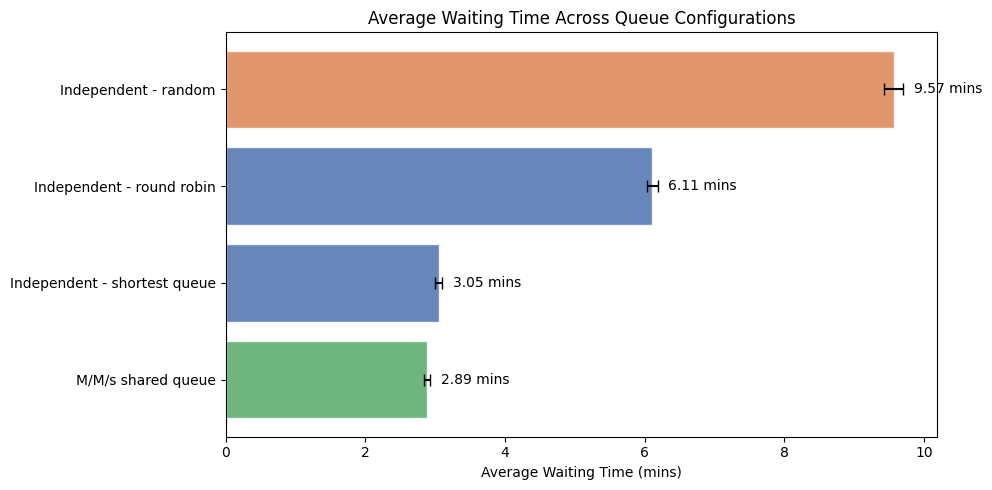

In [ ]:
# bar chart comparison
names = list(results_c.keys())
wait_means = [results_c[name]["mean"] for name in names]
wait_cis = [results_c[name]["ci95"] for name in names]

# sort by waiting time (best to worst)
sorted_idx = np.argsort(wait_means)
names_sorted = [names[i] for i in sorted_idx]
means_sorted = [wait_means[i] for i in sorted_idx]
cis_sorted = [wait_cis[i] for i in sorted_idx]

colors = ['#55A868' if i == 0 else '#DD8452' if i == len(names)-1 else '#4C72B0' 
          for i in range(len(names))]

plt.figure(figsize=(10, 5))
bars = plt.barh(range(len(names_sorted)), means_sorted, xerr=cis_sorted, capsize=4,
                color=colors, edgecolor='white', alpha=0.85)

# add value labels on bars
for i, (bar, mean) in enumerate(zip(bars, means_sorted)):
    plt.text(mean + cis_sorted[i] + 0.15, bar.get_y() + bar.get_height()/2,
             f'{mean:.2f} mins', va='center', fontsize=10)

plt.yticks(range(len(names_sorted)), names_sorted, fontsize=10)
plt.xlabel("Average Waiting Time (mins)")
plt.title("Average Waiting Time Across Queue Configurations")
plt.tight_layout()
plt.show()

### Results: Comparison of Queue Configurations

- **M/M/s shared queue (2.89 mins):** The current single shared queue design achieves the lowest waiting time. The pooling effect ensures that no server sits idle while customers are waiting.
- **Independent - shortest queue (3.05 mins):** Slightly worse than M/M/s. Although customers choose the best-looking queue at arrival, they commit to it and cannot switch if the situation changes. This small inefficiency adds up.
- **Independent - round robin (6.11 mins):** Roughly double the shared queue wait time. Mechanically cycling customers ignores queue state entirely, leading to imbalanced loads across servers.
- **Independent - random (9.57 mins):** Over 3x worse than the shared queue. Random assignment creates the most uneven distribution of customers across servers.

The results confirm that the current shared queue design is superior to all independent queue alternatives. If management proceeds with independent queues, shortest queue routing is essential — without it, waiting times increase dramatically.

### Varying the Number of Servers

In the analysis above, we used s = 3 servers as observed at the Japanese station. We wanted to investigate what happens if we add or remove servers.

Here, we fix each server's individual service rate at μ_individual = 0.933 customers/min (as estimated from observations where we saw 3 servers in the Japanese cafeteria) and vary the number of servers from 2 to 5. The total arrival rate λ = 2.52 customers/min remains unchanged, as the number of customers arriving at the station is independent of how many servers are operating.

This simulates the effect of staffing decisions like hiring an additional server or reducing to fewer servers — on average customer waiting time under the independent queue (shortest queue routing) configuration.

In [63]:
# effect of number of servers (fixed individual service rate)
server_counts = [2, 3, 4, 5]
server_results = {}

for s_var in server_counts:
    avg_waits = []
    for run in range(n):
        random.seed(run)
        wt = simulate_independent(d, s_var, arrival_rate_est, mu_individual, 'shortest')
        avg_waits.append(sum(wt) / len(wt))
    server_results[s_var] = {
        "mean": np.mean(avg_waits),
        "ci95": 1.96 * np.std(avg_waits, ddof=1) / np.sqrt(n)
    }
    print(f"s={s_var}: Avg Wq = {np.mean(avg_waits):.4f} mins")



s=2: Avg Wq = 6926.6459 mins
s=3: Avg Wq = 3.0506 mins
s=4: Avg Wq = 0.4884 mins
s=5: Avg Wq = 0.2424 mins


### Results: Effect of Number of Servers

- **s = 2:** The system is unstable as total service capacity (2 × 0.933 = 1.87 customers/min) is less than the arrival rate (λ = 2.52 customers/min). The queue grows without bound, resulting in extremely high waiting times. This confirms that 2 servers cannot handle rush hour demand.
- **s = 3:** The system is stable with waiting time of ~3.05 mins. This is the minimum number of servers needed to maintain a functioning queue.
- **s = 4:** Waiting time drops significantly to ~0.49 mins, a substantial improvement from adding just one extra server.
- **s = 5:** Diminishing returns — waiting time reduces only marginally further to ~0.24 mins.

This analysis suggests that **3 servers is the minimum viable staffing level** during rush hour. If management wants to reduce waiting times further, adding a 4th server provides the largest marginal improvement.

Note: s=2 excluded from chart (unstable system, Avg Wq = 6927 mins)


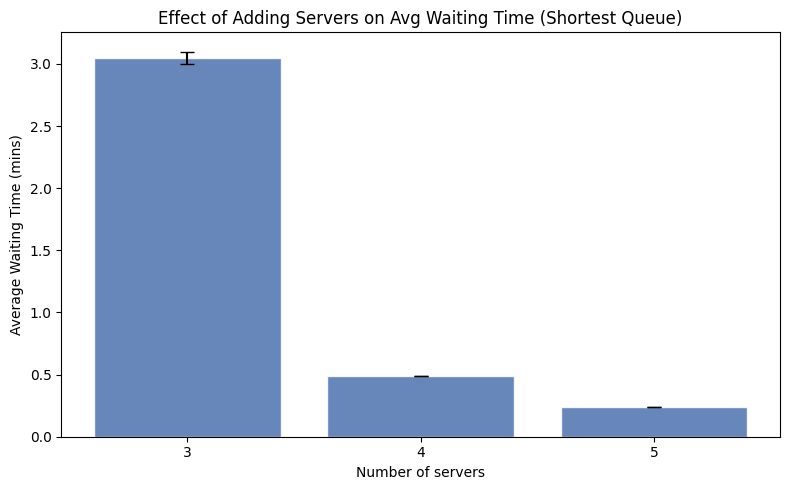

In [62]:
# plot only stable configurations
stable_counts = [sv for sv in server_counts if sv * mu_individual > arrival_rate_est]
print(f"Note: s=2 excluded from chart (unstable system, Avg Wq = {server_results[2]['mean']:.0f} mins)")

plt.figure(figsize=(8, 5))
plt.bar([str(sv) for sv in stable_counts],
        [server_results[sv]["mean"] for sv in stable_counts],
        yerr=[server_results[sv]["ci95"] for sv in stable_counts],
        capsize=5, color='#4C72B0', edgecolor='white', alpha=0.85)
plt.xlabel("Number of servers")
plt.ylabel("Average Waiting Time (mins)")
plt.title("Effect of Adding Servers on Avg Waiting Time (Shortest Queue)")
plt.tight_layout()
plt.show()

### Sensitivity Analysis: Non-Exponential Service Times

The exponential service time assumption implies high variability as some customers served in seconds, others in minutes. In reality, food preparation times are likely more consistent. We test robustness by replacing exponential service times with an Erlang distribution (k=3), which has the same mean but lower variance (variance reduced by a factor of k). If our conclusions hold under both distributions, the recommendation to management is robust regardless of the true service time distribution.

In [58]:
# Erlang sampling: sum of k exponential samples 
# mean service time is preserved: E[Erlang] = k/(k*mu) = 1/mu
def sample_erlang(mu, k):
    return sum(exponential_sample(k * mu) for _ in range(k))

In [59]:
# rerun M/M/s and independent queues with Erlang service times
k_erlang = 3

configs_erlang = [
    ("M/M/s shared (exponential)",    "mms",   "exponential"),
    ("M/E/s shared (Erlang k=3)",     "mms",   "erlang"),
    ("Indep shortest (exponential)",  "indep", "exponential"),
    ("Indep shortest (Erlang k=3)",   "indep", "erlang"),
]

results_erlang = {}

for name, queue_type, service_dist in configs_erlang:
    print(f"Running: {name}...")
    avg_waits = []

    for run in range(n):
        random.seed(run)
        interarrival_times = [exponential_sample(arrival_rate_est) for _ in range(d)]

        server_free_at = [0.0] * s
        waiting_times = [0.0] * d
        arrival_time = 0.0

        for i in range(d):
            if i > 0:
                arrival_time += interarrival_times[i-1]

            # queue type determines server selection
            if queue_type == 'mms':
                chosen = min(range(s), key=lambda x: server_free_at[x])
            elif queue_type == 'indep':
                queue_lengths = [0] * s
                for q in range(s):
                    queue_lengths[q] = max(0, int((server_free_at[q] - arrival_time) * mu_individual)) if server_free_at[q] > arrival_time else 0
                min_len = min(queue_lengths)
                ties = [q for q in range(s) if queue_lengths[q] == min_len]
                chosen = random.choice(ties)

            service_start = max(arrival_time, server_free_at[chosen])
            waiting_times[i] = service_start - arrival_time

            # service distribution determines service time
            if service_dist == 'exponential':
                service_time = exponential_sample(mu_individual)
            elif service_dist == 'erlang':
                service_time = sample_erlang(mu_individual, k_erlang)

            server_free_at[chosen] = service_start + service_time

        avg_waits.append(sum(waiting_times) / d)

    avg_waits = np.array(avg_waits)
    results_erlang[name] = {
        "mean": avg_waits.mean(),
        "ci95": 1.96 * avg_waits.std(ddof=1) / np.sqrt(n)
    }

print("\nDone.")

Running: M/M/s shared (exponential)...
Running: M/E/s shared (Erlang k=3)...
Running: Indep shortest (exponential)...
Running: Indep shortest (Erlang k=3)...

Done.


In [60]:
# results table
rows_e = []
for name, res in results_erlang.items():
    rows_e.append({
        "Configuration": name,
        "Avg Waiting Time (mins)": round(res["mean"], 4),
        "95% CI (±)": round(res["ci95"], 4)
    })

df_e = pd.DataFrame(rows_e)
print("=== Exponential vs Erlang Service Times ===\n")
print(df_e.to_string(index=False))

=== Exponential vs Erlang Service Times ===

               Configuration  Avg Waiting Time (mins)  95% CI (±)
  M/M/s shared (exponential)                   2.8874      0.0413
   M/E/s shared (Erlang k=3)                   1.9554      0.0259
Indep shortest (exponential)                   3.0506      0.0492
 Indep shortest (Erlang k=3)                   2.1206      0.0225


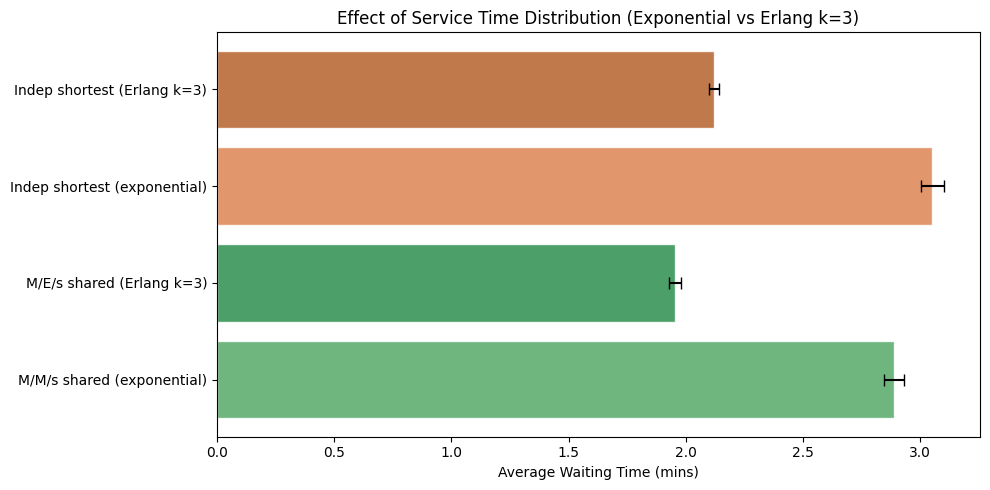

In [61]:
# bar chart
names_e = list(results_erlang.keys())
means_e = [results_erlang[name]["mean"] for name in names_e]
cis_e = [results_erlang[name]["ci95"] for name in names_e]

plt.figure(figsize=(10, 5))
plt.barh(range(len(names_e)), means_e, xerr=cis_e, capsize=4,
         color=['#55A868', '#2D8E4F', '#DD8452', '#B5622A'],
         edgecolor='white', alpha=0.85)
plt.yticks(range(len(names_e)), names_e, fontsize=10)
plt.xlabel("Average Waiting Time (mins)")
plt.title("Effect of Service Time Distribution (Exponential vs Erlang k=3)")
plt.tight_layout()
plt.show()

### Results: Exponential vs Erlang Service Times

- Switching from exponential to Erlang (k=3) service times **reduces waiting times across all configurations**, as expected. Lower variance in service times means fewer extreme delays that cause queues to build up.
- M/M/s shared queue drops from 2.89 to 1.96 mins (32% reduction). Independent shortest queue drops from 3.05 to 2.12 mins (31% reduction).
- Crucially, the **relative ranking is unchanged**: the shared queue still outperforms independent queues under both distributions. This confirms that our recommendation to retain the shared queue is robust regardless of the true service time distribution.
- The reduction in waiting times suggests that if service times are indeed more regular than exponential (which is likely for food preparation), the actual waiting times experienced by customers may be lower than the exponential-based estimates in Parts B and C.